# CNN — Clasificación de TC Cerebrales

**Proyecto:** Stroke Predictor  
**Módulo:** Imágenes (independiente del pipeline tabular)  
**Dataset:** `data/cnn/normal/` + `data/cnn/stroke/`

| | |
|---|---|
| Normal | 1551 imágenes |
| Stroke | 950 imágenes |
| Total | 2501 imágenes |
| Desbalance | 1.6:1 — manejable con class_weight |

## Índice
1. Setup e importaciones
2. EDA — exploración del dataset
3. Pipeline de datos
4. Baseline — CNN desde cero
5. Transfer Learning — EfficientNetB0
6. Comparativa y selección del modelo
7. Evaluación final + Grad-CAM
8. Guardado y MLflow

---
## 1 · Setup e importaciones

In [3]:
print("kernel")

kernel


In [ ]:
import os
import gc
import json
import warnings
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.model_selection import train_test_split

import mlflow
import mlflow.keras

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

tf.data.experimental.enable_debug_mode()  # solo debug puntual

# ── Memory growth — CRÍTICO para WSL ──

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'✓ Memory growth activado — {gpus[0].name}')

# ── Paths ──
ROOT       = Path('../..')
CNN_DIR    = ROOT / 'data' / 'cnn'
NORMAL_DIR = CNN_DIR / 'normal'
STROKE_DIR = CNN_DIR / 'stroke'
MODEL_DIR  = ROOT / 'models' / 'cnn'
ASSETS_DIR = ROOT / 'assets' / 'cnn'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# ── Reproducibilidad ──
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── MLflow ──
MLFLOW_EXP = 'stroke_cnn'
mlflow.set_tracking_uri(f"file:///mnt/c/Users/under/Documents/F5/3_Projects/Stroker_project/mlruns")
mlflow.set_experiment(MLFLOW_EXP)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU disponible     : {len(gpus) > 0}')
print(f'Normal dir         : {NORMAL_DIR}')
print(f'Stroke dir         : {STROKE_DIR}')

2026-04-29 22:19:28.644370: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/under/miniconda3/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Memory growth activado — /physical_device:GPU:0
TensorFlow version : 2.20.0
GPU disponible     : True
Normal dir         : ../../data/cnn/normal
Stroke dir         : ../../data/cnn/stroke


---
## 2 · EDA — Exploración del dataset

In [ ]:
# ── Conteo de imágenes y cálculo de ratio ──

IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

normal_paths = [p for p in NORMAL_DIR.iterdir() if p.suffix.lower() in IMG_EXTENSIONS]
stroke_paths = [p for p in STROKE_DIR.iterdir() if p.suffix.lower() in IMG_EXTENSIONS]
all_paths    = normal_paths + stroke_paths

print(f'Imágenes Normal : {len(normal_paths)}')
print(f'Imágenes Stroke : {len(stroke_paths)}')
print(f'Total           : {len(all_paths)}')
print(f'Ratio N/S       : {len(normal_paths)/len(stroke_paths):.2f}:1')
print(f'Extensiones     : {dict(Counter(p.suffix.lower() for p in all_paths))}')

Imágenes Normal : 1551
Imágenes Stroke : 950
Total           : 2501
Ratio N/S       : 1.63:1
Extensiones     : {'.jpg': 2501}


In [ ]:
# ── Exploración de tamaño de las imágenes ──

sample_size  = min(200, len(all_paths))
sample_paths = np.random.choice(all_paths, size=sample_size, replace=False)

widths, heights, channels_list = [], [], []
for p in sample_paths:
    try:
        arr = img_to_array(load_img(p))
        heights.append(arr.shape[0])
        widths.append(arr.shape[1])
        channels_list.append(arr.shape[2] if len(arr.shape) == 3 else 1)
    except Exception as e:
        print(f'  ⚠️ {p.name}: {e}')

print(f'Tamaños (muestra {sample_size}):')
print(f'  Alto  — min: {min(heights)}  max: {max(heights)}  media: {np.mean(heights):.0f}')
print(f'  Ancho — min: {min(widths)}   max: {max(widths)}   media: {np.mean(widths):.0f}')
print(f'  Canales únicos: {set(channels_list)}')
print(f'  Tamaño uniforme: {"✓ Sí" if len(set(zip(heights,widths)))==1 else "✗ No"}')

Tamaños (muestra 200):
  Alto  — min: 650  max: 650  media: 650
  Ancho — min: 650   max: 650   media: 650
  Canales únicos: {3}
  Tamaño uniforme: ✓ Sí


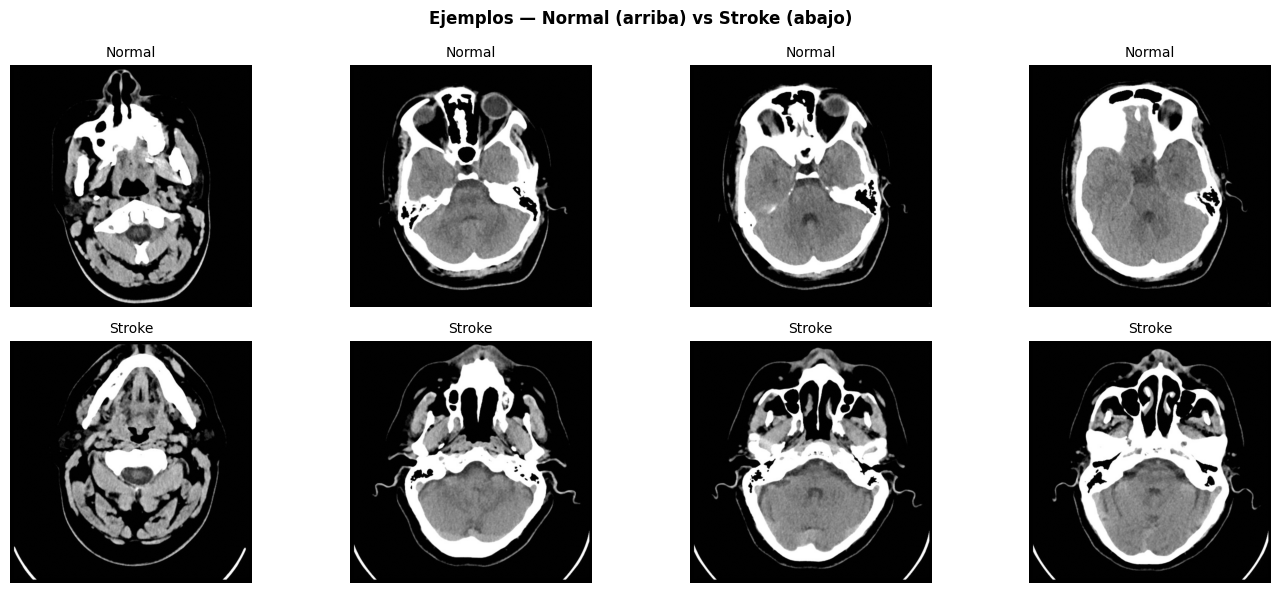

In [ ]:
# ── Ejemplo visual del dataset ──

n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(14, 6))
fig.suptitle('Ejemplos — Normal (arriba) vs Stroke (abajo)', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes[0]):
    ax.imshow(img_to_array(load_img(normal_paths[i], color_mode='grayscale')).squeeze(), cmap='gray')
    ax.set_title('Normal', fontsize=10); ax.axis('off')

for i, ax in enumerate(axes[1]):
    ax.imshow(img_to_array(load_img(stroke_paths[i], color_mode='grayscale')).squeeze(), cmap='gray')
    ax.set_title('Stroke', fontsize=10); ax.axis('off')

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'eda_samples.png', dpi=100, bbox_inches='tight')
plt.show()

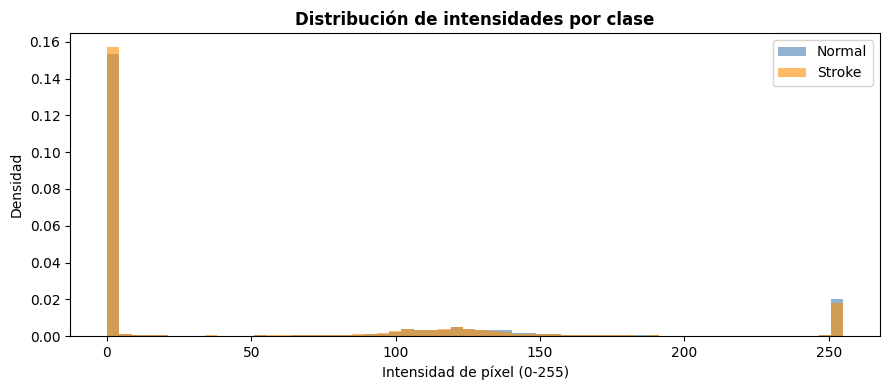

Normal — media: 54.0  std: 83.8
Stroke — media: 50.1  std: 80.7


In [ ]:
# ── Distribución de intensidades por clase ──

def sample_intensities(paths, n=100):
    sampled = np.random.choice(paths, size=min(n, len(paths)), replace=False)
    return np.concatenate([
        img_to_array(load_img(p, color_mode='grayscale')).flatten()
        for p in sampled
    ])

normal_px = sample_intensities(normal_paths)
stroke_px = sample_intensities(stroke_paths)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(normal_px, bins=60, alpha=0.6, color='steelblue',  label='Normal', density=True)
ax.hist(stroke_px, bins=60, alpha=0.6, color='darkorange', label='Stroke', density=True)
ax.set_xlabel('Intensidad de píxel (0-255)'); ax.set_ylabel('Densidad')
ax.set_title('Distribución de intensidades por clase', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'eda_intensity.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Normal — media: {normal_px.mean():.1f}  std: {normal_px.std():.1f}')
print(f'Stroke — media: {stroke_px.mean():.1f}  std: {stroke_px.std():.1f}')

---
## 3 · Pipeline de datos

| Parámetro | Valor | Razón |
|---|---|---|
| Resize | 224×224 | Estándar Transfer Learning |
| Canales | RGB (3) | EfficientNet lo requiere |
| Normalización baseline | /255.0 → [0,1] | Estándar CNN |
| Normalización EfficientNet | sin normalizar [0,255] | EfficientNet normaliza internamente |
| Split | 70/15/15 | Train/Val/Test estratificado |
| Augmentation | Solo en train | Flip H + contraste leve |

In [ ]:
IMG_SIZE   = (224, 224)
IMG_SHAPE  = (224, 224, 3)
BATCH_SIZE = 16             #Reducción de 32 por limitaciones
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15

print(f'IMG_SIZE   : {IMG_SIZE}')
print(f'BATCH_SIZE : {BATCH_SIZE}')
print(f'Split      : {1-VAL_SPLIT-TEST_SPLIT:.0%} / {VAL_SPLIT:.0%} / {TEST_SPLIT:.0%}')

IMG_SIZE   : (224, 224)
BATCH_SIZE : 16
Split      : 70% / 15% / 15%


In [ ]:
# ── Split estratificado ──

records = (
    [{'path': str(p), 'label': 0} for p in normal_paths] +
    [{'path': str(p), 'label': 1} for p in stroke_paths]
)
df_imgs = pd.DataFrame(records).sample(frac=1, random_state=SEED).reset_index(drop=True)

df_train, df_temp = train_test_split(
    df_imgs, test_size=VAL_SPLIT + TEST_SPLIT,
    stratify=df_imgs['label'], random_state=SEED
)
df_val, df_test = train_test_split(
    df_temp, test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    stratify=df_temp['label'], random_state=SEED
)

print(f'Train : {len(df_train):4d} | Normal: {(df_train.label==0).sum()} | Stroke: {(df_train.label==1).sum()}')
print(f'Val   : {len(df_val):4d} | Normal: {(df_val.label==0).sum()} | Stroke: {(df_val.label==1).sum()}')
print(f'Test  : {len(df_test):4d} | Normal: {(df_test.label==0).sum()} | Stroke: {(df_test.label==1).sum()}')

# class_weight — fórmula estándar sklearn
n_normal = (df_train.label == 0).sum()
n_stroke = (df_train.label == 1).sum()
total    = len(df_train)
CLASS_WEIGHT = {
    0: total / (2 * n_normal),
    1: total / (2 * n_stroke)
}
print(f'\nclass_weight: {CLASS_WEIGHT}')

Train : 1750 | Normal: 1085 | Stroke: 665
Val   :  375 | Normal: 233 | Stroke: 142
Test  :  376 | Normal: 233 | Stroke: 143

class_weight: {0: np.float64(0.8064516129032258), 1: np.float64(1.3157894736842106)}


In [ ]:
# ── Pipeline para Baseline CNN — normalizado [0, 1] ──
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_contrast(img, 0.95, 1.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(df, augment_data=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((df['path'].values, df['label'].values))
    ds = ds.map(load_image, num_parallel_calls=2)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=2)
    if shuffle:
        ds = ds.shuffle(500, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(1)


# ── Pipeline para EfficientNet — SIN normalizar [0, 255] ──
# EfficientNetB0 incluye su propia normalización interna.
# Pasarle [0,1] produce features incorrectas y el modelo no aprende.
def load_image_efficientnet(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)  # ← sin /255.0
    return img, label

def augment_efficientnet(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_contrast(img, 0.95, 1.05)
    img = tf.clip_by_value(img, 0.0, 255.0)  # ← clip en escala [0,255]
    return img, label

def make_dataset_efficientnet(df, augment_data=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((df['path'].values, df['label'].values))
    ds = ds.map(load_image_efficientnet, num_parallel_calls=2)
    if augment_data:
        ds = ds.map(augment_efficientnet, num_parallel_calls=2)
    if shuffle:
        ds = ds.shuffle(500, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(1)


# ── Construir todos los datasets ──
ds_train = make_dataset(df_train, augment_data=True,  shuffle=True)
ds_val   = make_dataset(df_val,   augment_data=False, shuffle=False)
ds_test  = make_dataset(df_test,  augment_data=False, shuffle=False)

ds_train_eff = make_dataset_efficientnet(df_train, augment_data=True,  shuffle=True)
ds_val_eff   = make_dataset_efficientnet(df_val,   augment_data=False, shuffle=False)
ds_test_eff  = make_dataset_efficientnet(df_test,  augment_data=False, shuffle=False)

print(f'✓ Datasets baseline    : train={len(ds_train)} val={len(ds_val)} test={len(ds_test)} batches')
print(f'✓ Datasets EfficientNet: train={len(ds_train_eff)} val={len(ds_val_eff)} test={len(ds_test_eff)} batches')

I0000 00:00:1777493993.144097    2362 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4055 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


✓ Datasets baseline    : train=110 val=24 test=24 batches
✓ Datasets EfficientNet: train=110 val=24 test=24 batches


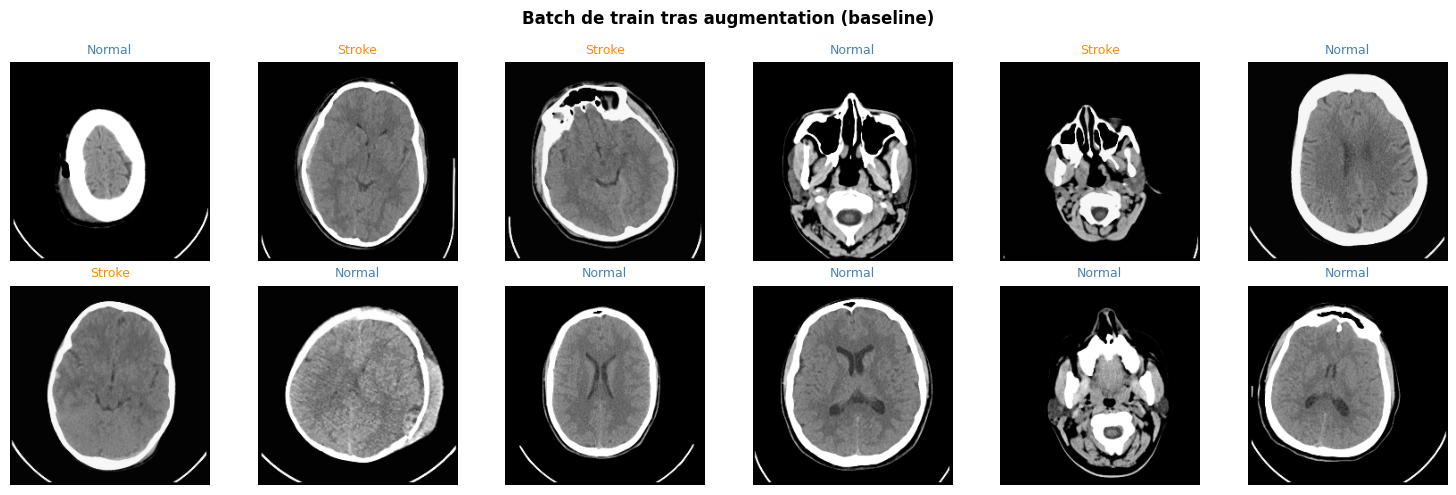

Shape: (16, 224, 224, 3) | Rango: [0.00, 1.00]


In [ ]:
# ── Verificación visual ──

sample_imgs, sample_labels = next(iter(ds_train))

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Batch de train tras augmentation (baseline)', fontsize=12, fontweight='bold')
label_names = {0: 'Normal', 1: 'Stroke'}
colors      = {0: 'steelblue', 1: 'darkorange'}

for i, ax in enumerate(axes.flat):
    if i >= len(sample_imgs): break
    img = sample_imgs[i].numpy()
    lbl = int(sample_labels[i].numpy())
    ax.imshow(img, cmap='gray')
    ax.set_title(label_names[lbl], color=colors[lbl], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'pipeline_sample_batch.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Shape: {sample_imgs.shape} | Rango: [{sample_imgs.numpy().min():.2f}, {sample_imgs.numpy().max():.2f}]')

---
## 4 · Baseline — CNN desde cero

Arquitectura mínima: 3 bloques Conv→BN→Pool + cabeza clasificadora.  
Función: establecer un punto de referencia y validar el pipeline.

In [ ]:
# ── Arquitectura de Baseline CNN desde cero ──

def build_baseline_cnn(input_shape=IMG_SHAPE) -> Model:
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs, name='baseline_cnn')


model_baseline = build_baseline_cnn()
model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.AUC(name='auc', curve='ROC'),
        keras.metrics.AUC(name='pr_auc', curve='PR'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
    ]
)
model_baseline.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,425 (497.75 KB)

 Trainable params: 126,977 (496.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ── Control y optimización durante el entrenamiento ──

def get_callbacks(model_name: str, patience: int = 10) -> list:
    """Callbacks compartidos para baseline y EfficientNet."""
    return [
        EarlyStopping(
            monitor='val_auc', mode='max',
            patience=patience, restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_auc', mode='max',
            factor=0.5, patience=5, min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            filepath=str(MODEL_DIR / f'{model_name}_best.keras'),
            monitor='val_auc', mode='max',
            save_best_only=True, verbose=0
        ),
    ]

print('✓ Callbacks definidos')

✓ Callbacks definidos


In [13]:
print('Entrenando CNN baseline...')

history_baseline = model_baseline.fit(
    ds_train,
    validation_data=ds_val,
    epochs=50,
    class_weight=CLASS_WEIGHT,
    callbacks=get_callbacks('baseline_cnn'),
    verbose=1
)

print('\n✓ Entrenamiento baseline completado')

Entrenando CNN baseline...
Epoch 1/50


2026-04-29 22:20:08.219895: I external/local_xla/xla/service/service.cc:163] XLA service 0x73ee88089280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-29 22:20:08.219964: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-04-29 22:20:08.417225: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-29 22:20:09.177104: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-04-29 22:20:10.553302: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,32,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call

  1/110 ━━━━━━━━━━━━━━━━━━━━ 25:11 14s/step - auc: 0.3646 - loss: 0.7305 - pr_auc: 0.1987 - precision: 0.1538 - recall: 0.5000

I0000 00:00:1777494015.725898    4174 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - auc: 0.5316 - loss: 0.7035 - pr_auc: 0.3951 - precision: 0.3933 - recall: 0.5795

2026-04-29 22:20:22.963676: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[6,32,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-04-29 22:20:23.100675: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[6,64,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,32,112,112]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="_

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - auc: 0.5319 - loss: 0.7034 - pr_auc: 0.3954 - precision: 0.3936 - recall: 0.5791

2026-04-29 22:20:30.091942: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_2', 184 bytes spill stores, 184 bytes spill loads

2026-04-29 22:20:33.175938: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,32,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-04-29 22:20:33.257324: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omi

110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 202ms/step - auc: 0.5477 - loss: 0.6986 - pr_auc: 0.4133 - precision: 0.4081 - recall: 0.5609 - val_auc: 0.5455 - val_loss: 0.7292 - val_pr_auc: 0.4374 - val_precision: 0.3787 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - auc: 0.5701 - loss: 0.6893 - pr_auc: 0.4467 - precision: 0.4199 - recall: 0.6271 - val_auc: 0.5553 - val_loss: 0.8201 - val_pr_auc: 0.4556 - val_precision: 0.3787 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - auc: 0.6098 - loss: 0.6746 - pr_auc: 0.4775 - precision: 0.4461 - recall: 0.5970 - val_auc: 0.6262 - val_loss: 0.8953 - val_pr_auc: 0.4984 - val_precision: 0.3787 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - auc: 0.6269 - loss: 0.6674 - pr_auc: 0.5087 - precision: 0.4526 - recall: 0.5955 - val_auc: 0.6599 - val_loss: 0.9133 - val_pr_auc: 0.5234 - val_precis

In [ ]:
def plot_history(history, title: str, save_path: Path):
    """Curvas de entrenamiento: Loss, AUC y Recall."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    pairs = [
        ('loss',   'val_loss',   'Loss',   'steelblue'),
        ('auc',    'val_auc',    'AUC',    'forestgreen'),
        ('recall', 'val_recall', 'Recall', 'darkorange'),
    ]
    for ax, (tr, vl, label, color) in zip(axes, pairs):
        if tr in history.history:
            ax.plot(history.history[tr], color=color, lw=2, label='Train')
            ax.plot(history.history[vl], color=color, lw=2, ls='--', label='Val', alpha=0.7)
        ax.set_title(label); ax.set_xlabel('Epoch')
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

print('\n✓ Función para las gráficas creado')

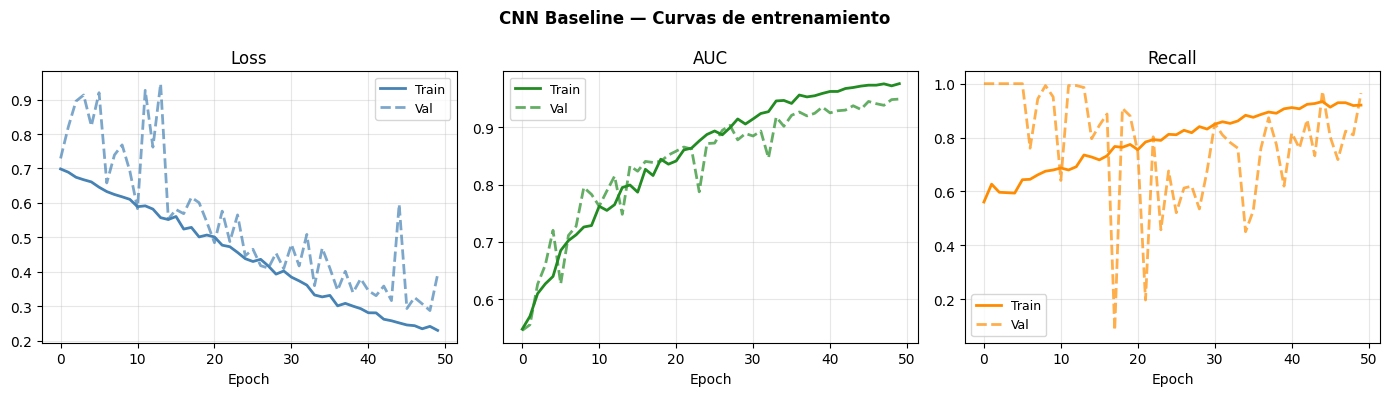

In [15]:
plot_history(history_baseline, 'CNN Baseline — Curvas de entrenamiento',
             ASSETS_DIR / 'baseline_history.png')

In [ ]:
# ── Guardar baseline antes de limpiar sesión para EfficientNet ──
# Necesario porque clear_session() elimina el modelo de memoria.
BASELINE_PATH = MODEL_DIR / 'baseline_cnn_best.keras'
model_baseline.save(BASELINE_PATH)
print(f'✓ Baseline guardado: {BASELINE_PATH}')

# Limpiar sesión para liberar VRAM antes de EfficientNet
del model_baseline
tf.keras.backend.clear_session()
gc.collect()
print('✓ Sesión limpiada — VRAM liberada para EfficientNet')

✓ Baseline guardado: ../../models/cnn/baseline_cnn_best.keras
✓ Sesión limpiada — VRAM liberada para EfficientNet


---
## 5 · Transfer Learning — EfficientNetB0

**Estrategia en dos fases:**
- **Fase 1** — Backbone congelado, solo cabeza. 15 epochs, lr=1e-4.
- **Fase 2** — Fine-tuning últimas 20 capas. 35 epochs, lr=1e-5.

**Nota sobre los warnings de XLA en epoch 1:**  
Los mensajes `slow_operation_alarm` aparecen solo en el primer epoch — es el autotuner de XLA buscando el algoritmo óptimo para las convoluciones depthwise de EfficientNet. A partir del epoch 2 desaparecen. No afectan al entrenamiento.

In [ ]:
# ── Silenciar XLA autotune verbose ──
os.environ['XLA_FLAGS']    = '--xla_gpu_autotune_level=0'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'
tf.config.optimizer.set_jit(False)

def build_efficientnet(input_shape=IMG_SHAPE, freeze_base: bool = True) -> Model:
    """
    EfficientNetB0 preentrenado en ImageNet.
    freeze_base=True  → Fase 1: solo cabeza entrenable.
    freeze_base=False → Fase 2: fine-tuning de últimas 20 capas.

    IMPORTANTE: el input debe estar en [0, 255] — EfficientNet
    normaliza internamente. Usar ds_train_eff, no ds_train.
    """
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base.trainable = not freeze_base

    if not freeze_base:
        for layer in base.layers[:-20]:
            layer.trainable = False
        trainable = sum(1 for l in base.layers if l.trainable)
        print(f'  Capas entrenables backbone: {trainable}/{len(base.layers)}')

    inputs  = keras.Input(shape=input_shape)
    x       = base(inputs, training=not freeze_base)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs, name='efficientnet_b0')


print('Construyendo EfficientNetB0 — Fase 1 (backbone congelado)...')
model_eff = build_efficientnet(freeze_base=True)
print(f'Parámetros totales     : {model_eff.count_params():,}')
print(f'Parámetros entrenables : {sum(tf.size(v).numpy() for v in model_eff.trainable_variables):,}')

Construyendo EfficientNetB0 — Fase 1 (backbone congelado)...
Parámetros totales     : 4,218,788
Parámetros entrenables : 166,657


In [ ]:
model_eff.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
    ]
)

print('Fase 1 — Entrenando cabeza (backbone congelado)...')

history_eff_p1 = model_eff.fit(
    ds_train_eff,
    validation_data=ds_val_eff,
    epochs=15,
    class_weight=CLASS_WEIGHT,
    callbacks=get_callbacks('efficientnet_phase1', patience=7),
    verbose=1
)

print('\n✓ Fase 1 completada')
print(f'  Mejor val_auc : {max(history_eff_p1.history["val_auc"]):.4f}')
print(f'  Mejor val_recall : {max(history_eff_p1.history["val_recall"]):.4f}')

Fase 1 — Entrenando cabeza (backbone congelado)...
  (warnings XLA solo en epoch 1 — normal)
Epoch 1/15


2026-04-29 22:30:01.308709: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[16,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,480,14,14]{3,2,1,0}, f32[480,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-04-29 22:30:01.990079: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.68237225s
Trying algorithm eng3{k11=2} for conv (f32[16,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,480,14,14]{3,2,1,0}, f32[480,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$

108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - auc: 0.5304 - loss: 0.8755 - precision: 0.4097 - recall: 0.6197

2026-04-29 22:30:30.280203: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[6,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,480,14,14]{3,2,1,0}, f32[480,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-04-29 22:30:31.216833: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.936765652s
Trying algorithm eng3{k11=2} for conv (f32[6,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,480,14,14]{3,2,1,0}, f32[480,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$con

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - auc: 0.5310 - loss: 0.8747 - precision: 0.4099 - recall: 0.6193

2026-04-29 22:31:04.038717: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 22:31:04.340130: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 22:31:04.629776: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 22:31:04.633500: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[7,672,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,672,14,14]{3,2,1,0}, f32[672,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, featur

110/110 ━━━━━━━━━━━━━━━━━━━━ 103s 559ms/step - auc: 0.5632 - loss: 0.8323 - precision: 0.4152 - recall: 0.6000 - val_auc: 0.6464 - val_loss: 0.6468 - val_precision: 0.4902 - val_recall: 0.5282 - learning_rate: 1.0000e-04
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - auc: 0.6709 - loss: 0.7006 - precision: 0.4988 - recall: 0.6361 - val_auc: 0.7312 - val_loss: 0.6060 - val_precision: 0.5595 - val_recall: 0.6620 - learning_rate: 1.0000e-04
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - auc: 0.7450 - loss: 0.6126 - precision: 0.5655 - recall: 0.6947 - val_auc: 0.7610 - val_loss: 0.5730 - val_precision: 0.6013 - val_recall: 0.6690 - learning_rate: 1.0000e-04
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - auc: 0.7666 - loss: 0.5914 - precision: 0.5767 - recall: 0.7293 - val_auc: 0.8058 - val_loss: 0.5383 - val_precision: 0.6199 - val_recall: 0.7465 - learning_rate: 1.0000e-04
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step - auc: 0.7821 - loss: 0.5693 - prec

In [ ]:
gc.collect()
tf.keras.backend.clear_session()   # limpia grafos intermedios

# Recargar el checkpoint guardado por ModelCheckpoint
model_eff = keras.models.load_model(
    str(MODEL_DIR / 'efficientnet_phase1_best.keras')
)
print('✓ Modelo Fase 1 recargado desde checkpoint')
print('  VRAM liberada y reconstruida desde disco')

✓ Modelo Fase 1 recargado desde checkpoint
  VRAM liberada y reconstruida desde disco


In [ ]:
# ── Fase 2 — Fine-tuning de últimas 20 capas ──
# lr=1e-5 crítico: evita destruir los pesos preentrenados de ImageNet
print('Fase 2 — Fine-tuning (últimas 20 capas del backbone)...')

base_layer = model_eff.layers[1]  # EfficientNetB0
base_layer.trainable = True
for layer in base_layer.layers[:-20]:
    layer.trainable = False

model_eff.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
    ]
)

history_eff_p2 = model_eff.fit(
    ds_train_eff,
    validation_data=ds_val_eff,
    epochs=30,
    class_weight=CLASS_WEIGHT,
    callbacks=get_callbacks('efficientnet_final', patience=5),
    verbose=1
)

print('\n✓ Fine-tuning completado')
print(f'  Mejor val_auc    : {max(history_eff_p2.history["val_auc"]):.4f}')
print(f'  Mejor val_recall : {max(history_eff_p2.history["val_recall"]):.4f}')

Fase 2 — Fine-tuning (últimas 20 capas del backbone)...
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 68s 319ms/step - auc: 0.7962 - loss: 0.5655 - precision: 0.6171 - recall: 0.7368 - val_auc: 0.8616 - val_loss: 0.4772 - val_precision: 0.6667 - val_recall: 0.8028 - learning_rate: 1.0000e-05
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - auc: 0.8214 - loss: 0.5300 - precision: 0.6261 - recall: 0.7504 - val_auc: 0.8581 - val_loss: 0.4781 - val_precision: 0.6802 - val_recall: 0.8239 - learning_rate: 1.0000e-05
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - auc: 0.8278 - loss: 0.5159 - precision: 0.6336 - recall: 0.7594 - val_auc: 0.8616 - val_loss: 0.4638 - val_precision: 0.6970 - val_recall: 0.8099 - learning_rate: 1.0000e-05
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - auc: 0.8357 - loss: 0.5066 - precision: 0.6606 - recall: 0.7579 - val_auc: 0.8673 - val_loss: 0.4605 - val_precision: 0.6941 - val_recall: 0.8310 - learning_rate: 1.0000e-05
Epoch 5/30
110/110 ━━━━━

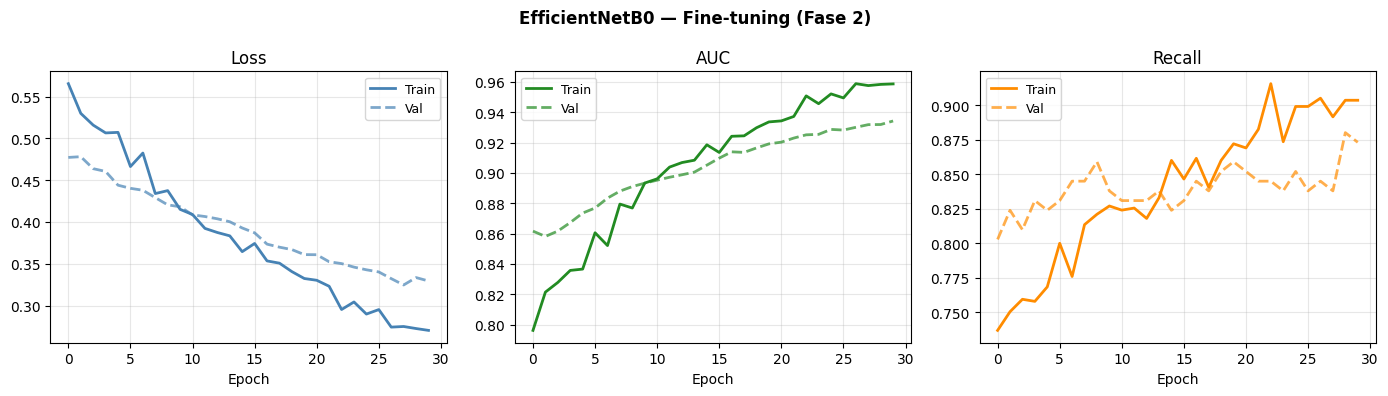

In [21]:
plot_history(history_eff_p2, 'EfficientNetB0 — Fine-tuning (Fase 2)',
             ASSETS_DIR / 'efficientnet_history.png')

---
## 6 · Comparativa y selección del modelo

Se recarga el baseline desde disco (fue guardado antes de `clear_session`). Ambos modelos se evalúan sobre el **mismo test set** con el **mismo threshold**.

In [ ]:
THRESHOLD_CNN = 0.5


def evaluate_cnn(model, ds, threshold=0.5, name='model'):
    """Evaluación en test set — mismas métricas que el pipeline tabular."""
    y_true, y_prob = [], []
    for imgs, labels in ds:
        y_prob.extend(model.predict(imgs, verbose=0).flatten())
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        'name':      name,
        'auc':       round(roc_auc_score(y_true, y_prob), 4),
        'recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'f1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
    }, y_true, y_prob, y_pred


# Recargar baseline desde disco
print(f'Cargando baseline desde {BASELINE_PATH}...')
model_baseline_eval = keras.models.load_model(BASELINE_PATH)

print('Evaluando modelos en test set...')
metrics_baseline, y_true_b, y_prob_b, y_pred_b = evaluate_cnn(
    model_baseline_eval, ds_test, THRESHOLD_CNN, 'Baseline CNN'
)

metrics_eff, y_true_e, y_prob_e, y_pred_e = evaluate_cnn(
    model_eff, ds_test_eff, THRESHOLD_CNN, 'EfficientNetB0'
)

# Tabla comparativa
df_cnn_compare = pd.DataFrame([metrics_baseline, metrics_eff])
print('\n══ Comparativa CNN — Test Set ══')
display(
    df_cnn_compare.set_index('name').style
    .highlight_max(subset=['auc', 'recall'], color='#c6efce')
    .format({'auc': '{:.4f}', 'recall': '{:.4f}',
             'precision': '{:.4f}', 'f1': '{:.4f}'})
)

winner_name = 'EfficientNetB0' if metrics_eff['auc'] >= metrics_baseline['auc'] else 'Baseline CNN'
print(f'\n🏆 Mejor modelo: {winner_name}')

Cargando baseline desde ../../models/cnn/baseline_cnn_best.keras...
Evaluando modelos en test set...


2026-04-29 22:40:21.203344: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,32,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-04-29 22:40:21.361125: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,64,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,32,112,112]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="_


══ Comparativa CNN — Test Set ══


,auc,recall,precision,f1
name,,,,
Baseline CNN,0.9537,0.9720,0.6651,0.7898
EfficientNetB0,0.9618,0.9021,0.8269,0.8629



🏆 Mejor modelo: EfficientNetB0


---
## 7 · Evaluación final + Grad-CAM

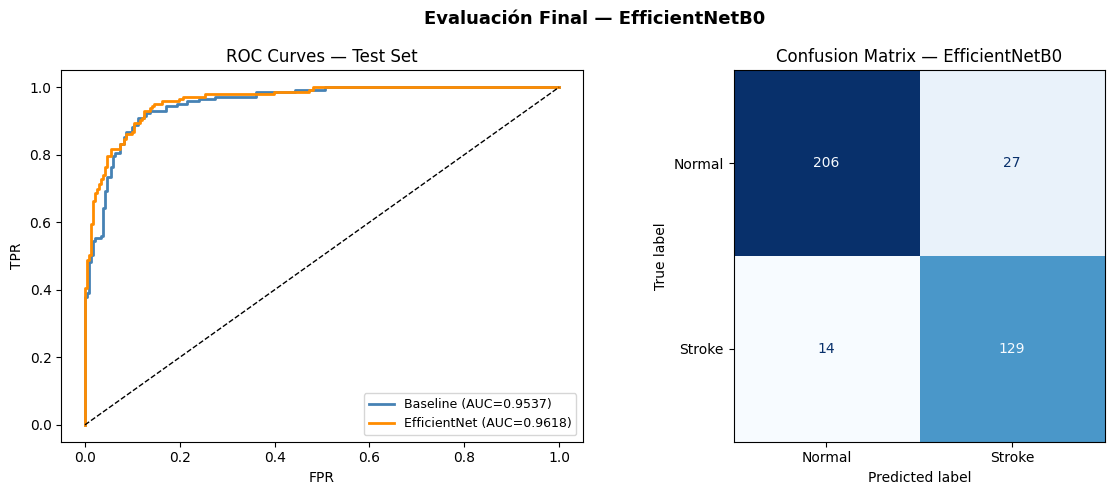

TN=206  FP=27  FN=14  TP=129
Stroke no detectados (FN): 14


In [ ]:
# ── Selección automática del ganador ──
if metrics_eff['auc'] >= metrics_baseline['auc']:
    best_model  = model_eff
    best_metrics = metrics_eff
    y_true_best, y_prob_best, y_pred_best = y_true_e, y_prob_e, y_pred_e
    best_name   = 'EfficientNetB0'
    best_ds_test = ds_test_eff
else:
    best_model  = model_baseline_eval
    best_metrics = metrics_baseline
    y_true_best, y_prob_best, y_pred_best = y_true_b, y_prob_b, y_pred_b
    best_name   = 'Baseline_CNN'
    best_ds_test = ds_test

# ── ROC + Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Evaluación Final — {best_name}', fontsize=13, fontweight='bold')

for mets, y_t, y_p, label, color in [
    (metrics_baseline, y_true_b, y_prob_b, f'Baseline (AUC={metrics_baseline["auc"]})', 'steelblue'),
    (metrics_eff,      y_true_e, y_prob_e, f'EfficientNet (AUC={metrics_eff["auc"]})',  'darkorange'),
]:
    fpr, tpr, _ = roc_curve(y_t, y_p)
    axes[0].plot(fpr, tpr, lw=2, color=color, label=label)
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — Test Set'); axes[0].legend(fontsize=9)

ConfusionMatrixDisplay(
    confusion_matrix(y_true_best, y_pred_best),
    display_labels=['Normal', 'Stroke']
).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix — {best_name}')

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'cnn_final_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = confusion_matrix(y_true_best, y_pred_best).ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Stroke no detectados (FN): {fn}')

In [ ]:
# ── Verificación del nombre de las capas ──

backbone = model_eff.get_layer('efficientnetb0')
conv_layers = [l.name for l in backbone.layers if 'conv' in l.name.lower()]
print('Últimas 5 capas conv del backbone:')
for name in conv_layers[-5:]:
    print(f'  {name}')

Últimas 5 capas conv del backbone:
  block6d_project_conv
  block7a_expand_conv
  block7a_dwconv
  block7a_project_conv
  top_conv


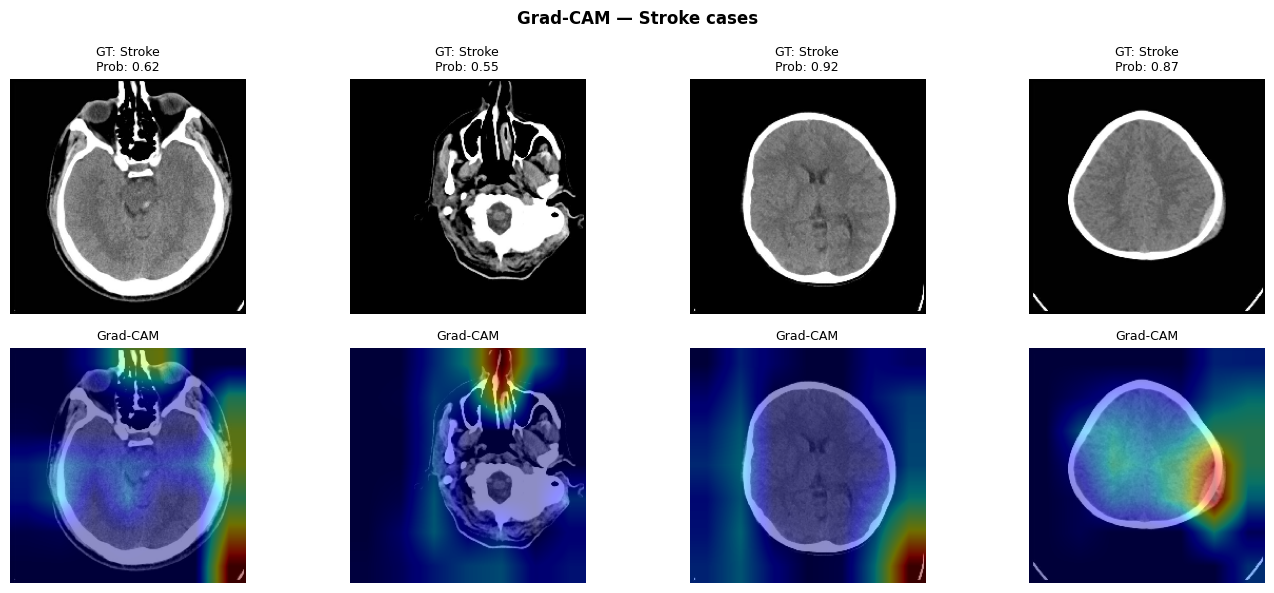

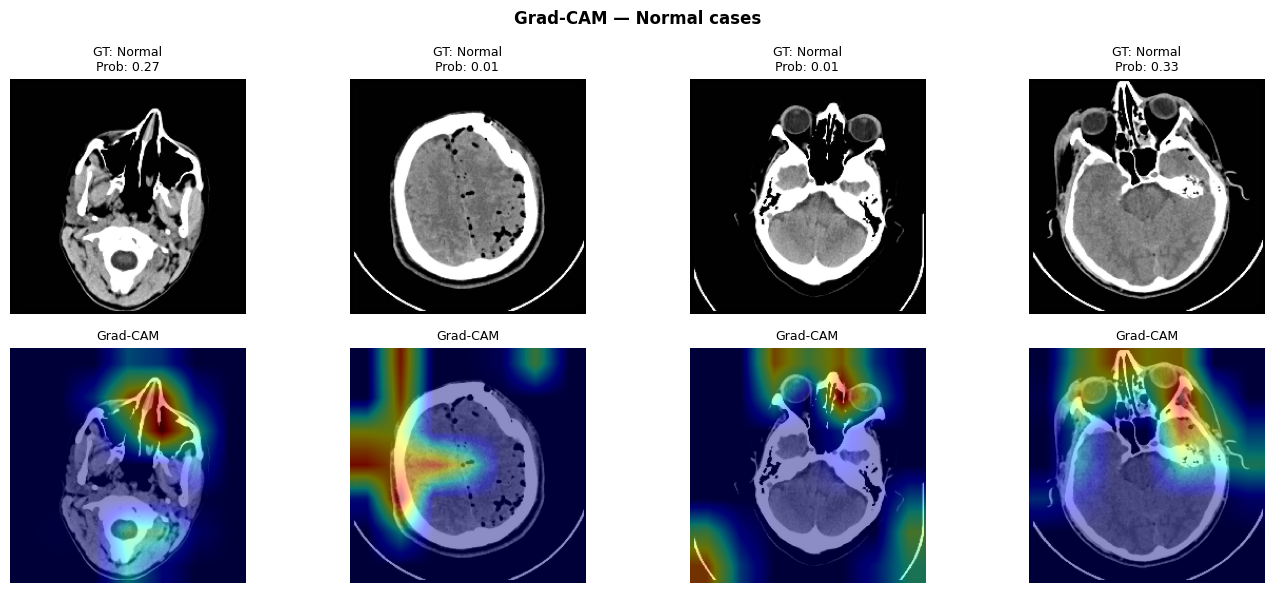

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    backbone  = next((l for l in model.layers if hasattr(l, 'layers')), None)
    img_tensor = tf.cast(img_array, tf.float32)

    if backbone is not None:
        # Modelo 1: input → top_conv
        feat_extractor = Model(
            backbone.input,
            backbone.get_layer(last_conv_layer_name).output
        )

        # Capas del backbone DESPUÉS de top_conv (top_bn, top_activation)
        layers_after_conv = []
        found = False
        for layer in backbone.layers:
            if found:
                layers_after_conv.append(layer)
            if layer.name == last_conv_layer_name:
                found = True

        # Capas de la cabeza del modelo externo (GAP, BN, Dense, Dropout, Dense)
        head_layers = [
            l for l in model.layers
            if l.name not in [model.layers[0].name, backbone.name]
        ]

        # Modelo 2: top_conv_output → predicción final
        top_conv_shape = feat_extractor.output_shape[1:]
        clf_input = keras.Input(shape=top_conv_shape)
        x = clf_input
        for layer in layers_after_conv + head_layers:
            x = layer(x)
        classifier = Model(clf_input, x)

        # ── Grad-CAM ──────────────────────────────────────────────────────────
        # tape.watch(conv_outputs) ANTES de classifier → tape traza el camino
        with tf.GradientTape() as tape:
            conv_outputs = feat_extractor(img_tensor, training=False)
            tape.watch(conv_outputs)          # ← clave: watch antes de classifier
            predictions  = classifier(conv_outputs, training=False)
            loss         = predictions[:, 0]

        grads = tape.gradient(loss, conv_outputs)

    else:
        # Baseline CNN — modelo plano
        grad_model = Model(
            inputs=model.inputs,
            outputs=[model.get_layer(last_conv_layer_name).output, model.output]
        )
        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_tensor, training=False)
            tape.watch(conv_outputs)
            loss = predictions[:, 0]
        grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        raise ValueError('Gradientes None — ruta computacional cortada')

    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam     = tf.reduce_sum(tf.multiply(weights, conv_outputs[0]), axis=-1).numpy()
    cam     = np.maximum(cam, 0)
    cam     = cam / (cam.max() + 1e-8)
    return tf.image.resize(cam[..., np.newaxis], IMG_SIZE).numpy().squeeze()



def plot_gradcam(model, df_subset, last_conv, n_show=4,
                 title='Grad-CAM', normalize_input=True):
    """
    normalize_input=True  → cargar en [0,1]  (baseline)
    normalize_input=False → cargar en [0,255] (EfficientNet)
    """
    fig, axes = plt.subplots(2, n_show, figsize=(14, 6))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    for i in range(n_show):
        row   = df_subset.iloc[i]
        img   = img_to_array(load_img(row['path'], target_size=IMG_SIZE))
        img_display = img / 255.0  # siempre mostrar en [0,1]

        if normalize_input:
            inp = (img / 255.0)[np.newaxis, ...]
        else:
            inp = img[np.newaxis, ...]

        prob = float(model.predict(inp, verbose=0)[0][0])
        cam  = make_gradcam_heatmap(inp, model, last_conv)

        axes[0, i].imshow(img_display, cmap='gray')
        axes[0, i].set_title(
            f'GT: {"Stroke" if row["label"]==1 else "Normal"}\nProb: {prob:.2f}',
            fontsize=9
        )
        axes[0, i].axis('off')

        axes[1, i].imshow(img_display, cmap='gray')
        axes[1, i].imshow(cam, cmap='jet', alpha=0.45)
        axes[1, i].set_title('Grad-CAM', fontsize=9)
        axes[1, i].axis('off')

    plt.tight_layout()
    save_path = ASSETS_DIR / f'gradcam_{title.replace(" ","_").lower()}.png'
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()


# ── Nombre de la última capa conv según arquitectura ──
# Baseline CNN  → 'conv2d_2'
# EfficientNetB0 → 'top_conv'
LAST_CONV      = 'top_conv' if best_name == 'EfficientNetB0' else 'conv2d_2'
NORMALIZE_GRAD = best_name != 'EfficientNetB0'  # True=baseline, False=efficientnet

df_test_stroke = df_test[df_test['label'] == 1].reset_index(drop=True)
df_test_normal = df_test[df_test['label'] == 0].reset_index(drop=True)

plot_gradcam(best_model, df_test_stroke, LAST_CONV,
             title='Grad-CAM — Stroke cases', normalize_input=NORMALIZE_GRAD)
plot_gradcam(best_model, df_test_normal, LAST_CONV,
             title='Grad-CAM — Normal cases', normalize_input=NORMALIZE_GRAD)

---
## 8 · Guardado y MLflow

In [5]:
# Detenemos el proceso para evitar guardar pruebas

raise SystemExit("Deteniendo ejecución del notebook")

SystemExit: Deteniendo ejecución del notebook

In [34]:
model_save_path = MODEL_DIR / f'cnn_{best_name.lower()}_final.keras'
best_model.save(model_save_path)

cnn_metadata = {
    'model_name':   f'cnn_{best_name}',
    'architecture': best_name,
    'img_size':     list(IMG_SIZE),
    'threshold':    THRESHOLD_CNN,
    'input_range':  '[0,255]' if best_name == 'EfficientNetB0' else '[0,1]',
    'classes':      {'0': 'normal', '1': 'stroke'},
    'metrics':      {k: v for k, v in best_metrics.items() if k != 'name'}
}
with open(MODEL_DIR / 'cnn_metadata.json', 'w') as f:
    json.dump(cnn_metadata, f, indent=4)

print(f'✓ Modelo guardado : {model_save_path}')
print(f'✓ Metadata        : {MODEL_DIR / "cnn_metadata.json"}')

✓ Modelo guardado : ../../models/cnn/cnn_efficientnetb0_final.keras
✓ Metadata        : ../../models/cnn/cnn_metadata.json


In [35]:
with mlflow.start_run(run_name=f'cnn_{best_name}') as run:

    mlflow.log_param('architecture',  best_name)
    mlflow.log_param('img_size',      str(IMG_SIZE))
    mlflow.log_param('threshold',     THRESHOLD_CNN)
    mlflow.log_param('batch_size',    BATCH_SIZE)
    mlflow.log_param('class_weight',  str(CLASS_WEIGHT))
    mlflow.log_param('augmentation',  True)
    mlflow.log_param('input_range',   cnn_metadata['input_range'])
    mlflow.log_param('fine_tuning',   best_name == 'EfficientNetB0')

    for k, v in best_metrics.items():
        if k != 'name':
            mlflow.log_metric(k, v)

    mlflow.log_artifact(str(model_save_path))
    mlflow.log_artifact(str(MODEL_DIR / 'cnn_metadata.json'))
    for img_file in ASSETS_DIR.glob('*.png'):
        mlflow.log_artifact(str(img_file))

    RUN_ID = run.info.run_id

print(f'✓ MLflow run: {RUN_ID}')

sep = '─' * 55
print(f'\n{sep}')
print('  RESUMEN · CNN — Modelo Ganador')
print(sep)
print(f"  Arquitectura  : {best_name}")
print(f"  Input range   : {cnn_metadata['input_range']}")
print(f"  Threshold     : {THRESHOLD_CNN}")
print(f"  AUC           : {best_metrics['auc']}  {'✓' if best_metrics['auc'] >= 0.85 else '✗ < 0.85'}")
print(f"  Recall        : {best_metrics['recall']}  {'✓' if best_metrics['recall'] >= 0.75 else '✗ < 0.75'}")
print(f"  Precision     : {best_metrics['precision']}")
print(f"  F1            : {best_metrics['f1']}")
print(f"  MLflow run    : {RUN_ID}")
print(sep)

✓ MLflow run: 15d857b0fcc348c9ac0f33611cc61a6f

───────────────────────────────────────────────────────
  RESUMEN · CNN — Modelo Ganador
───────────────────────────────────────────────────────
  Arquitectura  : EfficientNetB0
  Input range   : [0,255]
  Threshold     : 0.5
  AUC           : 0.9618  ✓
  Recall        : 0.9021  ✓
  Precision     : 0.8269
  F1            : 0.8629
  MLflow run    : 15d857b0fcc348c9ac0f33611cc61a6f
───────────────────────────────────────────────────────
